In [44]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from numpy import mean, std
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../feature_engineering/data_for_temporal_model.csv')
# df = pd.read_csv('../../data_cleaning/data/imputed_data.csv', index_col=0)
# df.rename(columns={'person': 'participant'}, inplace=True)

In [45]:
# Encode target variable (genre)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['genre'])
num_classes = len(label_encoder.classes_)

# Features to use
features = ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm',
            'iris_diameter_mm', 'pupil_iris_ratio', 'centered_x', 'centered_y']

# Normalize features with standardscaler
scaler = StandardScaler()
scaler.fit(df[features])


# Filter participants
train_df = df[df['participant'].isin(['kenji', 'aimen'])]
test_df = df[df['participant'] == 'clara']

train_X = train_df[features]
test_X = test_df[features]
train_Y = train_df['label']
test_Y = test_df['label']

# Normalize features based on training set statistics

# Create sequences with fixed window size
def create_sequences(data, labels, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(labels.iloc[i + window_size - 1])  # label at the end of the window
    return np.array(X), to_categorical(np.array(y), num_classes=num_classes)

# Fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, epochs=15, batch_size=64, units=100, dropout_rate=0.5, dense_units=100, early_stopping_patience=10, verbose=2, learning_rate=5e-4):
    verbose = verbose
    n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]

    model = Sequential([
        Input(shape=(n_timesteps, n_features)),   # <-- define input here
        LSTM(units),                       
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dense(n_outputs, activation='softmax'),
    ])
    
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=early_stopping_patience, restore_best_weights=True)

    # Train
    history = model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stopping], validation_data=(testX, testy))
    
    # Evaluate
    preds = model.predict(testX, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(testy, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)

    #print accuracy
    accuracy = np.mean(y_true == y_pred) * 100
    print(f'Accuracy: {accuracy:.2f}%')

    return history, cm, cr, accuracy

# Summarize scores
def summarize_results(scores):
    print(scores)
    m, s = mean(scores), std(scores)
    print(f'Accuracy: {m:.3f}% (+/-{s:.3f})')

# Run experiment multiple times
def run_experiment(
    window_size=10, epochs=15, batch_size=64, repeats=10,
    units=100, dropout_rate=0.5, dense_units=100,
    verbose=2, learning_rate=5e-4
):
    X_train, y_train = create_sequences(train_X, train_df['label'], window_size)
    X_test,  y_test  = create_sequences(test_X,  test_df['label'],  window_size)

    histories = []
    cms       = []
    reports   = []
    accuracies = []
    for r in range(repeats):
        print(f"\n--- Run #{r+1} ---")
        history, cm, cr, accuracy = evaluate_model(
            X_train, y_train,
            X_test,  y_test,
            epochs=epochs,
            batch_size=batch_size,
            units=units,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            verbose=verbose,
            learning_rate=learning_rate
        )
        histories.append(history)
        cms.append(cm)
        reports.append(cr)
        accuracies.append(accuracy)

    return histories, cms, reports, accuracies

In [3]:
def plot_metrics(histories):
    epochs = max(len(h.history['loss']) for h in histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy subplot
    for idx, history in enumerate(histories, 1):
        axes[0].plot(history.history['accuracy'], label=f'Run {idx} Train', alpha=0.7)
        axes[0].plot(history.history['val_accuracy'], '--', label=f'Run {idx} Val', alpha=0.7)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)

    # Loss subplot
    for idx, history in enumerate(histories, 1):
        axes[1].plot(history.history['loss'], label=f'Run {idx} Train', alpha=0.7)
        axes[1].plot(history.history['val_loss'], '--', label=f'Run {idx} Val', alpha=0.7)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [49]:
histories, cms, reports, accuracies = run_experiment(window_size=25, epochs=50, batch_size=64, repeats=1, units=10, dropout_rate=0.7, dense_units=10, verbose=2, learning_rate=5e-4)
print(reports[0])


--- Run #1 ---
Epoch 1/50
82/82 - 2s - 23ms/step - accuracy: 0.3845 - loss: 1.1294 - val_accuracy: 0.5414 - val_loss: 1.0606
Epoch 2/50
82/82 - 0s - 6ms/step - accuracy: 0.4006 - loss: 1.0699 - val_accuracy: 0.6187 - val_loss: 1.0419
Epoch 3/50
82/82 - 0s - 6ms/step - accuracy: 0.4232 - loss: 1.0354 - val_accuracy: 0.5779 - val_loss: 1.0530
Epoch 4/50
82/82 - 0s - 6ms/step - accuracy: 0.4368 - loss: 1.0066 - val_accuracy: 0.6187 - val_loss: 1.0534
Epoch 5/50
82/82 - 0s - 6ms/step - accuracy: 0.4846 - loss: 0.9504 - val_accuracy: 0.5717 - val_loss: 1.0973
Epoch 6/50
82/82 - 0s - 6ms/step - accuracy: 0.5057 - loss: 0.9163 - val_accuracy: 0.6187 - val_loss: 1.0810
Epoch 7/50
82/82 - 0s - 6ms/step - accuracy: 0.5001 - loss: 0.9065 - val_accuracy: 0.6187 - val_loss: 1.1302
Epoch 8/50
82/82 - 0s - 6ms/step - accuracy: 0.4982 - loss: 0.9047 - val_accuracy: 0.6187 - val_loss: 1.1455
Epoch 9/50
82/82 - 0s - 6ms/step - accuracy: 0.5072 - loss: 0.8832 - val_accuracy: 0.6187 - val_loss: 1.1220
Ep

## Hyperparameter Tuning

In [37]:
import optuna
import numpy as np
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

# assume create_sequences() is defined as before,
# and df, train_df, test_df, label_encoder, num_classes are in scope

best_model = None  # to store the best model found during tuning

def build_model(input_shape, 
                n_layers, 
                units, 
                dropout_rate, 
                dense_units, 
                learning_rate):
    m = Sequential()
    m.add(Input(shape=input_shape))
    # stack n_layers LSTMs
    for i in range(n_layers):
        # all but last need to return sequences
        return_seq = (i < n_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq))
        m.add(Dropout(dropout_rate))
    m.add(Dense(dense_units, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return m

def objective(trial):
    # 1) hyperparameter search space
    window_size     = trial.suggest_int('window_size', 10, 100, step=10)
    n_layers        = trial.suggest_int('n_layers',    1,   3)
    units           = trial.suggest_categorical('units', [4,8,16,32,64])
    dropout_rate    = trial.suggest_float('dropout', 0.2, 0.8)
    dense_units     = trial.suggest_categorical('dense_units', [4,8,16,32,64])
    lr              = trial.suggest_float('lr', 1e-6, 1e-3, log=True)
    patience        = 5
    batch_size      = 32
    epochs          = 200  # will stop early

    # 2) build your train/val splits & scale
    X_train, y_train = create_sequences(train_X, train_df['label'], window_size)
    
    # simple 70/30 split for tuning
    N = len(X_train)
    idx = np.random.RandomState(42).permutation(N)
    train_n = int(0.7 * N)
    tr, va = idx[:train_n], idx[train_n:]
    X_tr, y_tr = X_train[tr], y_train[tr]
    X_va, y_va = X_train[va], y_train[va]

    input_shape = X_tr.shape[1:]  # (window_size, n_features)

    # 3) repeat training to average out randomness
    val_accs = []
    for _ in range(10):
        model = build_model(input_shape, n_layers, units, dropout_rate, dense_units, lr)
        es = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=0)
        hist = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=2
        )
        val_accs.append(hist.history['val_accuracy'][-1])
        print(f"Trial {trial.number} - Val Accuracy: {val_accs[-1]:.4f}")

    # 4) objective is mean validation accuracy
    if not best_model or np.mean(val_accs) > trial.study.best_value:
        best_model = model
        print(f"New best model found for trial {trial.number} with val accuracy: {np.mean(val_accs):.4f}")
        
    return np.mean(val_accs)

# 5) run the search
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best hyperparameters:", study.best_trial.params)


[I 2025-06-18 17:05:46,988] A new study created in memory with name: no-name-6d5c5255-baa1-482c-84be-fbe73a6512c2


Epoch 1/200
114/114 - 4s - 33ms/step - accuracy: 0.4158 - loss: 1.0986 - val_accuracy: 0.3933 - val_loss: 1.0986
Epoch 2/200
114/114 - 1s - 9ms/step - accuracy: 0.4191 - loss: 1.0985 - val_accuracy: 0.3933 - val_loss: 1.0985
Epoch 3/200
114/114 - 1s - 9ms/step - accuracy: 0.4191 - loss: 1.0985 - val_accuracy: 0.3933 - val_loss: 1.0985
Epoch 4/200
114/114 - 1s - 9ms/step - accuracy: 0.4191 - loss: 1.0984 - val_accuracy: 0.3933 - val_loss: 1.0984
Epoch 5/200
114/114 - 1s - 9ms/step - accuracy: 0.4191 - loss: 1.0983 - val_accuracy: 0.3933 - val_loss: 1.0984
Epoch 6/200
114/114 - 1s - 9ms/step - accuracy: 0.4191 - loss: 1.0983 - val_accuracy: 0.3933 - val_loss: 1.0984
Trial 0 - Val Accuracy: 0.3933
Epoch 1/200
114/114 - 6s - 55ms/step - accuracy: 0.3190 - loss: 1.1113 - val_accuracy: 0.2972 - val_loss: 1.1066
Epoch 2/200
114/114 - 1s - 10ms/step - accuracy: 0.3193 - loss: 1.1102 - val_accuracy: 0.2972 - val_loss: 1.1064
Epoch 3/200
114/114 - 1s - 11ms/step - accuracy: 0.3067 - loss: 1.1125

[W 2025-06-18 17:06:41,500] Trial 0 failed with parameters: {'window_size': 40, 'n_layers': 1, 'units': 4, 'dropout': 0.3096664181529214, 'dense_units': 32, 'lr': 2.0636748248476432e-06} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\kenji\OneDrive\Documenten\ML_QuantifiedSelf\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\kenji\AppData\Local\Temp\ipykernel_18364\755740099.py", line 66, in objective
    hist = model.fit(
           ^^^^^^^^^^
  File "c:\Users\kenji\OneDrive\Documenten\ML_QuantifiedSelf\.venv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kenji\OneDrive\Documenten\ML_QuantifiedSelf\.venv\Lib\site-packages\keras\src\backend\tensorflow\trainer.py", line 377, in fit
    logs = self.train_func

KeyboardInterrupt: 

In [43]:
import numpy as np
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# --- 1) Prepare your train/test sequences with the chosen window_size ---
window_size     = 60
n_layers        = 2
units           = 8
dropout_rate    = 0.7692998033215881
dense_units     = 16
learning_rate   = 0.0005257423723409036

X_train, y_train = create_sequences(train_X, train_df['label'], window_size)
X_test,  y_test  = create_sequences(test_X,  test_df['label'],  window_size)

N = len(X_train)
idx = np.random.RandomState(38).permutation(N)
train_n = int(0.7 * N)
tr, va = idx[:train_n], idx[train_n:]
X_tr, y_tr = X_train[tr], y_train[tr]
X_va, y_va = X_train[va], y_train[va]


# --- 2) Build the final model ---
def build_model(input_shape, 
                n_layers, 
                units, 
                dropout_rate, 
                dense_units, 
                learning_rate):
    m = Sequential()
    m.add(Input(shape=input_shape))
    # stack n_layers LSTMs
    for i in range(n_layers):
        # all but last need to return sequences
        return_seq = (i < n_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq))
        m.add(Dropout(dropout_rate))
    m.add(Dense(dense_units, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return m

input_shape = X_tr.shape[1:]  # (window_size, n_features)

model = build_model(input_shape, n_layers, units, dropout_rate, dense_units, learning_rate)
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=0)
hist = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=2
)
print("vallidation accuracy: ", hist.history['val_accuracy'][-1])

# --- 4) Final, unbiased evaluation on Clara ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy on Clara: {acc*100:.2f}%")

# Confusion matrix + full report
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
y_true = y_test.argmax(axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Epoch 1/200
114/114 - 7s - 58ms/step - accuracy: 0.3680 - loss: 1.0907 - val_accuracy: 0.4534 - val_loss: 1.0525
Epoch 2/200
114/114 - 3s - 24ms/step - accuracy: 0.4436 - loss: 1.0337 - val_accuracy: 0.6521 - val_loss: 0.9462
Epoch 3/200
114/114 - 3s - 24ms/step - accuracy: 0.5123 - loss: 0.9572 - val_accuracy: 0.7344 - val_loss: 0.8262
Epoch 4/200
114/114 - 3s - 23ms/step - accuracy: 0.5931 - loss: 0.8716 - val_accuracy: 0.8103 - val_loss: 0.6718
Epoch 5/200
114/114 - 3s - 23ms/step - accuracy: 0.6566 - loss: 0.7621 - val_accuracy: 0.8810 - val_loss: 0.4900
Epoch 6/200
114/114 - 3s - 24ms/step - accuracy: 0.7001 - loss: 0.6474 - val_accuracy: 0.9087 - val_loss: 0.3604
Epoch 7/200
114/114 - 3s - 23ms/step - accuracy: 0.7244 - loss: 0.5663 - val_accuracy: 0.9254 - val_loss: 0.2810
Epoch 8/200
114/114 - 3s - 23ms/step - accuracy: 0.7377 - loss: 0.5228 - val_accuracy: 0.9415 - val_loss: 0.2261
Epoch 9/200
114/114 - 3s - 24ms/step - accuracy: 0.7514 - loss: 0.4895 - val_accuracy: 0.9395 - 

# Good run below

In [ ]:
histories, cms, reports = run_experiment(window_size=45, epochs=50, batch_size=64, repeats=1, units=10, dropout_rate=0.5, dense_units=10, verbose=2, learning_rate=5e-4)


--- Run #1 ---
Epoch 1/50


c:\Users\kenji\OneDrive\Documenten\ML_QuantifiedSelf\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 - 3s - 32ms/step - accuracy: 0.4591 - loss: 1.0312 - val_accuracy: 0.2985 - val_loss: 1.1898
Epoch 2/50
82/82 - 1s - 16ms/step - accuracy: 0.5867 - loss: 0.9061 - val_accuracy: 0.2985 - val_loss: 1.1484
Epoch 3/50
82/82 - 1s - 16ms/step - accuracy: 0.6587 - loss: 0.7961 - val_accuracy: 0.3080 - val_loss: 1.1188
Epoch 4/50
82/82 - 1s - 15ms/step - accuracy: 0.7195 - loss: 0.6815 - val_accuracy: 0.3319 - val_loss: 1.0794
Epoch 5/50
82/82 - 1s - 15ms/step - accuracy: 0.8015 - loss: 0.5282 - val_accuracy: 0.3901 - val_loss: 1.0439
Epoch 6/50
82/82 - 1s - 16ms/step - accuracy: 0.9005 - loss: 0.3440 - val_accuracy: 0.4714 - val_loss: 0.9891
Epoch 7/50
82/82 - 1s - 15ms/step - accuracy: 0.9303 - loss: 0.2567 - val_accuracy: 0.5392 - val_loss: 0.9340
Epoch 8/50
82/82 - 1s - 16ms/step - accuracy: 0.9419 - loss: 0.2112 - val_accuracy: 0.5962 - val_loss: 0.9743
Epoch 9/50
82/82 - 1s - 16ms/step - accuracy: 0.9551 - loss: 0.1714 - val_accuracy: 0.6441 - val_loss: 0.9345
Epoch 10/50
82/82 - 1

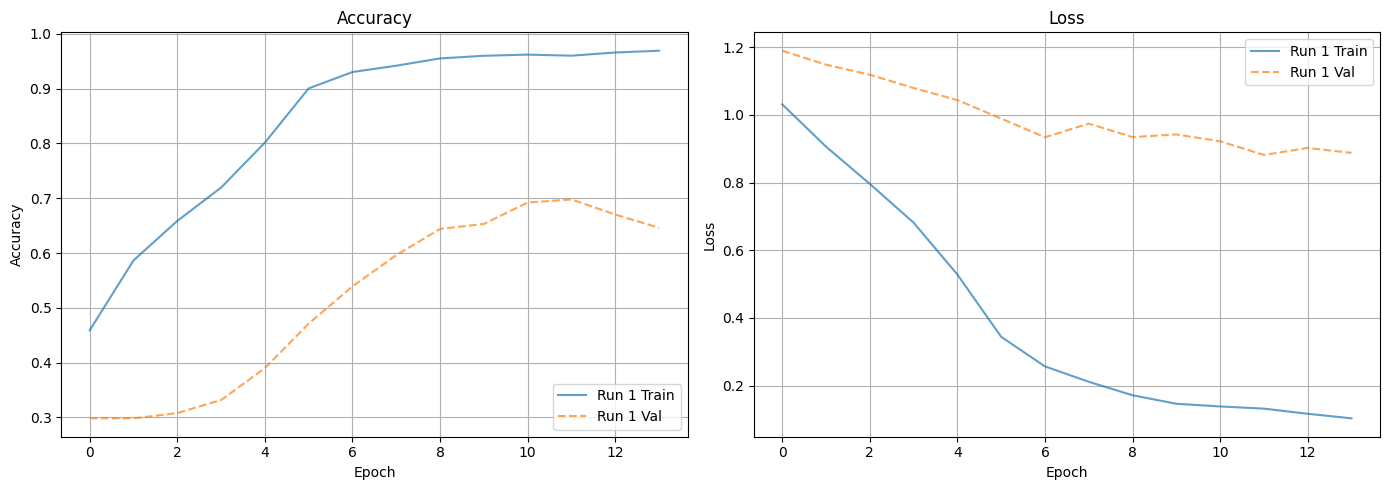

In [59]:
plot_metrics(histories[0])